## Imports and paths

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_DIR = Path.cwd()
RF_PATH = PROJECT_DIR / "Result" / "Random Forest" / "random_forest_auc_results.csv"
XGB_PATH = PROJECT_DIR / "Result" / "XGBoost" / "xgboost_auc_results.csv"

## 1 Read files

In [3]:
AUC_COL = "test_roc_auc"                                                                 # final AUC

rf_df = pd.read_csv(RF_PATH, encoding="utf-8-sig")                                       # read RF
xgb_df = pd.read_csv(XGB_PATH, encoding="utf-8-sig")                                     # read XGBoost

rf_df = rf_df[["country", "outcome", "mandate_period", "mandate_period_label", AUC_COL]].rename(columns={AUC_COL: "Random Forest AUC"})
xgb_df = xgb_df[["country", "outcome", "mandate_period", AUC_COL]].rename(columns={AUC_COL: "XGBoost AUC"})

auc_df = pd.merge(rf_df, xgb_df, on=["country", "outcome", "mandate_period"], how="inner") # merge AUC
auc_df["Outcome / Period"] = auc_df["outcome"] + " — " + auc_df["mandate_period_label"]

## 2 Visualization

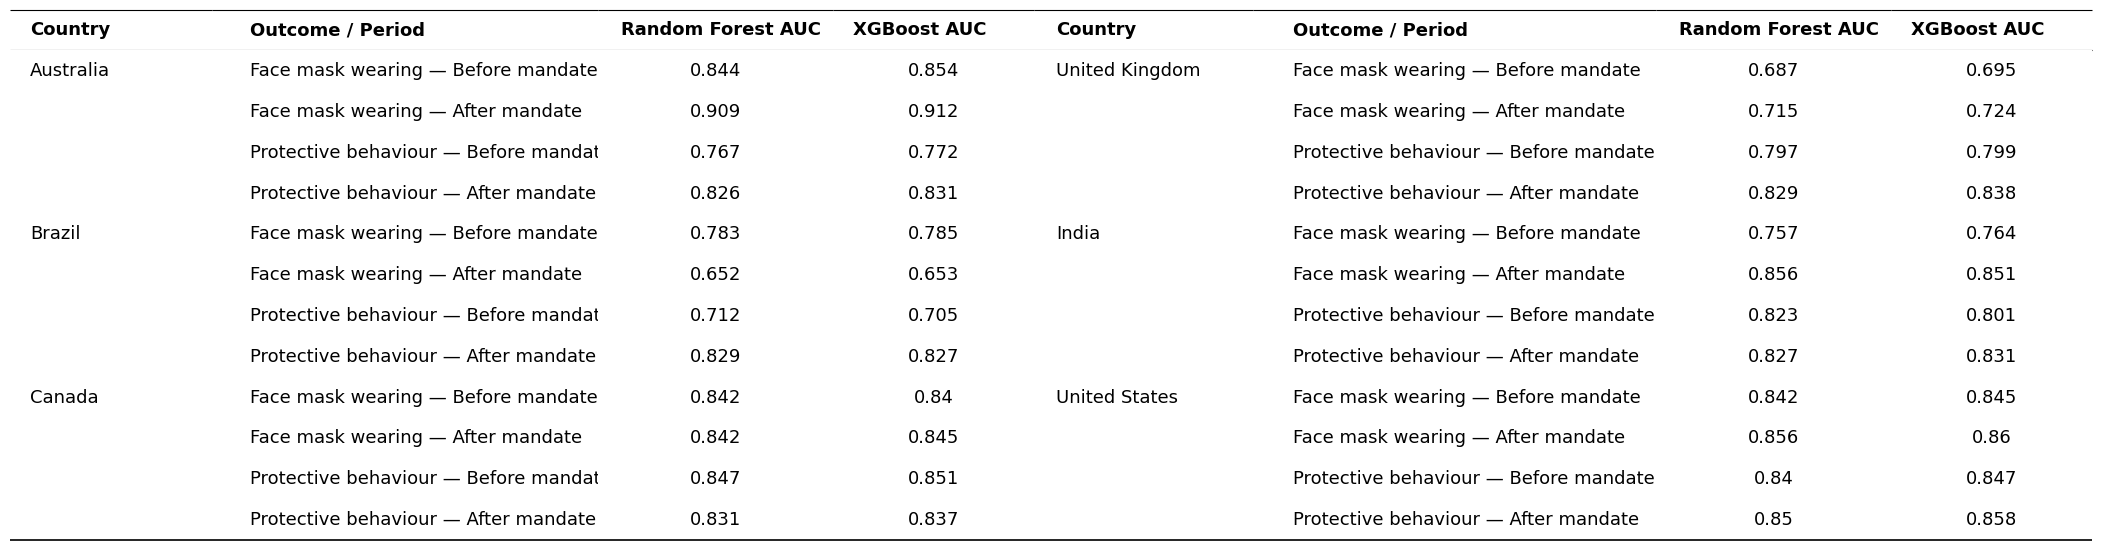

In [4]:
country_order = ["Australia", "Brazil", "Canada", "United Kingdom", "India", "United States"]
outcome_order = ["Face mask wearing — Before mandate", "Face mask wearing — After mandate", "Protective behaviour — Before mandate", "Protective behaviour — After mandate"]

auc_df["country"] = pd.Categorical(auc_df["country"], categories=country_order, ordered=True)
auc_df["Outcome / Period"] = pd.Categorical(auc_df["Outcome / Period"], categories=outcome_order, ordered=True)
auc_df = auc_df.sort_values(["country", "Outcome / Period"]).reset_index(drop=True)
auc_df["Random Forest AUC"] = auc_df["Random Forest AUC"].round(3)
auc_df["XGBoost AUC"] = auc_df["XGBoost AUC"].round(3)

left_countries = ["Australia", "Brazil", "Canada"]
right_countries = ["United Kingdom", "India", "United States"]
left_df = auc_df[auc_df["country"].isin(left_countries)][["country", "Outcome / Period", "Random Forest AUC", "XGBoost AUC"]].copy()
right_df = auc_df[auc_df["country"].isin(right_countries)][["country", "Outcome / Period", "Random Forest AUC", "XGBoost AUC"]].copy()
left_df["country"] = left_df["country"].astype(str)
right_df["country"] = right_df["country"].astype(str)
left_df.loc[left_df.duplicated("country"), "country"] = ""                               # clean country
right_df.loc[right_df.duplicated("country"), "country"] = ""

table_df = pd.concat([left_df.reset_index(drop=True), right_df.reset_index(drop=True)], axis=1)
table_df.columns = ["Country", "Outcome / Period", "Random Forest AUC", "XGBoost AUC", "Country", "Outcome / Period", "Random Forest AUC", "XGBoost AUC"]

fig, ax = plt.subplots(figsize=(21, 5.6))
ax.axis("off")

table = ax.table(cellText=table_df.values, colLabels=table_df.columns, cellLoc="left", colLoc="left", loc="center", colWidths=[0.12, 0.23, 0.14, 0.12, 0.13, 0.24, 0.14, 0.12])
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 2.0)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("white")
    cell.set_linewidth(0)
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.visible_edges = "BT"
        cell.set_edgecolor("black")
        cell.set_linewidth(0.8)

for row in range(1, len(table_df) + 1):
    for col in [2, 3, 6, 7]:
        table[(row, col)].set_text_props(ha="center")                                   # align AUC

for col in range(8):
    table[(len(table_df), col)].visible_edges = "B"
    table[(len(table_df), col)].set_edgecolor("black")
    table[(len(table_df), col)].set_linewidth(1.2)

plt.tight_layout()
plt.show()